# 06 - So sanh Face Recognition Models (ArcFace vs FaceNet vs MobileFaceNet)

**Muc tieu:** notebook nay so sanh 3 model **trich xuat embedding khuon mat** (khong phai
detection - xem `05_face_detector_comparison.ipynb` cho phan do) de cung co lua chon
ArcFace (`buffalo_l`, qua `insightface`) dang dung that trong `backend/app/services/
face_recognition_service.py`.

**3 model duoc so sanh:**

| Model | Kien truc / Loss | Embedding | Vai tro trong so sanh |
|---|---|---|---|
| **ArcFace** (`insightface`, buffalo_l, backbone ResNet50@WebFace600K) | ResNet + Additive Angular Margin Loss | 512-d | Model **dang dung that** trong `backend/` |
| **FaceNet** (`facenet-pytorch`, InceptionResnetV1, pretrained `vggface2`) | Inception + Triplet Loss | 512-d | Kien truc + ham loss khac han ArcFace, rat pho bien trong tai lieu hoc thuat |
| **MobileFaceNet** (`insightface`, buffalo_sc, backbone MBF@WebFace600K) | MobileNet-style depthwise conv, nhe (~1M tham so) + ArcFace loss | 512-d | Kien truc NHE, dai dien nhom mobile/edge - cung ho loss voi ArcFace nhung backbone nho hon nhieu |

**LUU Y VE THAY DOI SO VOI BAN DAU (v2):** ban dau du dinh dung **Dlib ResNet** (qua
`face_recognition`) lam model thu 3, nhung da doi sang **MobileFaceNet** vi ly do ky
thuat cu the: pip wheel chuan cua `dlib` **luon la CPU-only** (khong co CUDA build san
tren PyPI, chi co the co CUDA neu tu bien dich tu source voi CMake tim thay CUDA toolkit
luc build - qua trinh nay rat may rui tren Windows). Neu giu Dlib, so sanh toc do o Phan D
se khong con cong bang (2 model chay GPU vs 1 model bat buoc CPU). MobileFaceNet qua
`insightface` (buffalo_sc) dung CHINH XAC co che tai model + chay GPU qua ONNX Runtime
CUDA Execution Provider **giong het** ArcFace (buffalo_l) - da kiem chung hoat dong tu
Notebook 01/02 - nen khong co rui ro tuong thich GPU nhu Dlib.

**Phuong phap danh gia:** FAR (False Accept Rate) / FRR (False Reject Rate) / EER (Equal
Error Rate), **dung y het cach lam cua Notebook 04 - Phan A** de so sanh cong bang va nhat
quan voi ket qua da co cho ArcFace:
- **Genuine pairs:** anh trong `ai/dataset/splits/probe` (nguoi DA co trong gallery) so
  voi gallery embedding cua chinh ho -> do FRR (bi tu choi nham).
- **Impostor pairs:** them 1 batch nguoi tu LFW **chua tung dua vao gallery**
  (`min_faces_per_person=1`, loai nhung ai da co trong gallery) -> do FAR (nhan nham
  nguoi la thanh nguoi quen).
- Sweep threshold tu 0 den 1 (buoc 0.02) de ve duong FAR/FRR va tim EER cho **tung model
  rieng** - vi moi model co thang do similarity khac nhau. Ca 3 ham `get_embedding_*`
  o Phan A deu L2-normalize embedding truoc khi tra ve, nen `np.dot(a, b)` la cosine
  similarity cho CA 3 model, threshold sweep 0->1 dung chung duoc.

**Diem quan trong nhat can luu y:** ArcFace va MobileFaceNet dung CHUNG co che
`insightface.FaceAnalysis` (tu detect+align lai qua SCRFD noi bo cua tung model pack),
trong khi FaceNet chi resize 160x160 tren anh da align san 112x112 tu Notebook 01
(KHONG detect/align lai). Vi vay Phan A co 3 ham `get_embedding_<model>()` **rieng**,
KHONG dung chung 1 wrapper nhu Notebook 05.

**Phan cung:** RTX 5070 (12GB VRAM) - CA 3 MODEL deu chay duoc GPU trong notebook nay
(ArcFace + MobileFaceNet qua ONNX Runtime CUDA, FaceNet qua PyTorch CUDA) - khac voi
ban dau du dinh dung Dlib (CPU-only), nen so sanh FPS o Phan D lan nay cong bang giua
ca 3 model.

## Phan A - Cai dat thu vien va tai 3 model

`insightface` (dung cho CA ArcFace lan MobileFaceNet, 2 model pack khac nhau cua cung
1 thu vien) da co tu Notebook 01/02. Moi trong notebook nay: `facenet-pytorch` (FaceNet).

**CANH BAO QUAN TRONG ve `facenet-pytorch` (ban 2.6.0, phat hanh 2024, khong con duoc
cap nhat):** package nay khai bao cung (pin) `torch>=2.2.0,<2.3.0`, `torchvision>=0.17.0,
<0.18.0`, `numpy<2.0.0`, `Pillow<10.3.0` trong metadata. RTX 5070 (kien truc Blackwell,
sm_120) can `torch>=2.7.0` (build cu128 tro len) moi co CUDA kernel ho tro - neu
`pip install facenet-pytorch` binh thuong, pip se co HA CAP torch xuong `<2.3.0`, lam
MAT CUDA support tren GPU nay. Cai `--no-deps` de tranh dieu nay (xem Cell A1) - da kiem
tra ma nguon `InceptionResnetV1` chi dung API `torch.nn` pho thong, khong co kiem tra
`torch.__version__`, nen rui ro tuong thich la thap nhung khong bang 0.

In [1]:
# ===== CELL A1: Cai dat FaceNet (facenet-pytorch) =====
# facenet-pytorch (2.6.0) pin torch<2.3.0 trong metadata - RTX 5070 can torch>=2.7.0.
# Cai --no-deps de KHONG bi pip ha cap torch dang dung, roi tu cai bu dependency
# khong lien quan torch (requests, tqdm) rieng - xem canh bao chi tiet o markdown tren.
!pip install -q --no-deps facenet-pytorch
!pip install -q requests tqdm

print("Da cai: facenet-pytorch --no-deps (FaceNet)")
print("insightface da co tu Notebook 01/02, dung chung cho ArcFace (buffalo_l) va "
      "MobileFaceNet (buffalo_sc), khong can cai lai")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Da cai: facenet-pytorch --no-deps (FaceNet)
insightface da co tu Notebook 01/02, dung chung cho ArcFace (buffalo_l) va MobileFaceNet (buffalo_sc), khong can cai lai



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ===== CELL A1b: Xac nhan torch KHONG bi ha cap sau khi cai facenet-pytorch =====
import torch
print(f"Torch version sau khi cai facenet-pytorch: {torch.__version__}")
if torch.__version__.startswith(("2.0.", "2.1.", "2.2.")):
    print("CANH BAO: torch da bi ha cap xuong ban cu (< 2.3) - can go va cai lai "
          "torch>=2.7 (cu128) de chay duoc CUDA tren RTX 5070.")
else:
    print("Torch van dang o ban moi, chua bi facenet-pytorch keo xuong. On.")

Torch version sau khi cai facenet-pytorch: 2.11.0+cu128
Torch van dang o ban moi, chua bi facenet-pytorch keo xuong. On.


In [3]:
# ===== CELL A2: Duong dan project (giong quy uoc cac notebook truoc, dung lai gallery/probe) =====
import os
import pandas as pd

BASE_DIR = r'D:\face-security-system'
AI_DIR = os.path.join(BASE_DIR, 'ai')

SPLIT_GALLERY = os.path.join(AI_DIR, 'dataset', 'splits', 'gallery')   # anh align 112x112, tu Notebook 01
SPLIT_PROBE   = os.path.join(AI_DIR, 'dataset', 'splits', 'probe')     # anh align 112x112, tu Notebook 01
MODELS_DIR    = os.path.join(AI_DIR, 'models')
RESULTS_DIR   = os.path.join(AI_DIR, 'dataset', 'evaluation_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

GALLERY_PROBE_AVAILABLE = os.path.exists(SPLIT_GALLERY) and os.path.exists(SPLIT_PROBE)
if not GALLERY_PROBE_AVAILABLE:
    print("KHONG tim thay du lieu gallery/probe tai:")
    print(f"  Gallery: {SPLIT_GALLERY}")
    print(f"  Probe:   {SPLIT_PROBE}")
    print("Day la du lieu da tao o Notebook 01 (Buoc 3, Cell 10) - chay Notebook 01 truoc, "
          "hoac kiem tra lai BASE_DIR neu chay tren may khac.")
else:
    n_gallery_people = len(os.listdir(SPLIT_GALLERY))
    n_probe_people = len(os.listdir(SPLIT_PROBE))
    print(f"Da tim thay du lieu: {n_gallery_people} nguoi trong gallery, {n_probe_people} nguoi trong probe")

Da tim thay du lieu: 65 nguoi trong gallery, 65 nguoi trong probe


In [4]:
# ===== CELL A3: Kiem tra GPU (PyTorch cho FaceNet, ONNX Runtime cho ArcFace + MobileFaceNet) =====
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
device = "cuda" if torch.cuda.is_available() else "cpu"

import onnxruntime as ort
print(f"\nONNX Runtime providers: {ort.get_available_providers()}")
if "CUDAExecutionProvider" not in ort.get_available_providers():
    print("CANH BAO: khong co CUDAExecutionProvider - ArcFace va MobileFaceNet se chay "
          "CPU. Cai onnxruntime-gpu neu muon so sanh toc do cong bang (xem Notebook 05, "
          "Cell A1).")
else:
    print("CUDAExecutionProvider co san - ca 3 model trong notebook nay se chay GPU.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070

ONNX Runtime providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
CUDAExecutionProvider co san - ca 3 model trong notebook nay se chay GPU.


In [5]:
# ===== CELL A4: Tai model 1 - ArcFace (qua insightface, buffalo_l) - GIONG HET Notebook 02/04 =====
import cv2
import numpy as np
from insightface.app import FaceAnalysis

providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
arcface_app = FaceAnalysis(name="buffalo_l", providers=providers)
arcface_app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.3)  # det_thresh giong het config.py

PAD_RATIO = 0.4  # giong het face_recognition_service.py


def get_embedding_arcface(img_bgr):
    # Embedding ArcFace (512-d), padding truoc khi detect - giong het get_embedding()
    # trong face_recognition_service.py that. Tra ve None neu khong tim thay mat.
    if img_bgr is None or img_bgr.size == 0:
        return None
    h, w = img_bgr.shape[:2]
    pad_h, pad_w = int(h * PAD_RATIO), int(w * PAD_RATIO)
    padded = cv2.copyMakeBorder(img_bgr, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REFLECT)
    faces = arcface_app.get(padded)
    if not faces:
        return None
    best = max(faces, key=lambda f: f.det_score)
    emb = best.embedding.astype(np.float32)
    return emb / (np.linalg.norm(emb) + 1e-10)


print(f"Da tai ArcFace (buffalo_l), providers: {arcface_app.det_model.session.get_providers()}")

d:\face-security-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\Admin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

In [6]:
# ===== CELL A5: Tai model 2 - FaceNet (facenet-pytorch, InceptionResnetV1, pretrained vggface2) =====
from facenet_pytorch import InceptionResnetV1

facenet_model = InceptionResnetV1(pretrained="vggface2").eval().to(device)


def get_embedding_facenet(img_bgr):
    # Embedding FaceNet (512-d). Anh gallery/probe da align+crop 112x112 tu Notebook 01,
    # chi can resize ve 160x160 (input size chuan cua FaceNet), KHONG detect/align lai -
    # khac voi ArcFace o tren vi FaceNet trong notebook nay dung nhu 1 pure encoder.
    if img_bgr is None or img_bgr.size == 0:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (160, 160))
    # FaceNet (vggface2 pretrained) mong doi input chuan hoa ve [-1, 1]
    img_tensor = torch.from_numpy(img_resized).float().permute(2, 0, 1).unsqueeze(0)
    img_tensor = (img_tensor - 127.5) / 128.0
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        emb = facenet_model(img_tensor).cpu().numpy()[0].astype(np.float32)
    return emb / (np.linalg.norm(emb) + 1e-10)


print(f"Da tai FaceNet (InceptionResnetV1, pretrained=vggface2), dang chay tren: {device}")

Da tai FaceNet (InceptionResnetV1, pretrained=vggface2), dang chay tren: cuda


In [7]:
# ===== CELL A6: Tai model 3 - MobileFaceNet (qua insightface, buffalo_sc) =====
# buffalo_sc: detector SCRFD-500MF (nhe) + recognition MBF@WebFace600K (MobileFaceNet,
# depthwise conv, ~1M tham so - nhe hon nhieu so voi ResNet50 cua buffalo_l). Dung CHUNG
# co che FaceAnalysis nhu ArcFace o Cell A4 - insightface tu tai model pack qua registry
# chinh thuc (khong can URL ngoai), chay GPU qua CUDAExecutionProvider giong het ArcFace.
mobilefacenet_app = FaceAnalysis(name="buffalo_sc", providers=providers)
mobilefacenet_app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.3)


def get_embedding_mobilefacenet(img_bgr):
    # Embedding MobileFaceNet (512-d), cung logic padding+detect nhu ArcFace o Cell A4 -
    # 2 model dung chung kien truc pipeline cua insightface, chi khac model pack.
    if img_bgr is None or img_bgr.size == 0:
        return None
    h, w = img_bgr.shape[:2]
    pad_h, pad_w = int(h * PAD_RATIO), int(w * PAD_RATIO)
    padded = cv2.copyMakeBorder(img_bgr, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REFLECT)
    faces = mobilefacenet_app.get(padded)
    if not faces:
        return None
    best = max(faces, key=lambda f: f.det_score)
    emb = best.embedding.astype(np.float32)
    return emb / (np.linalg.norm(emb) + 1e-10)


print(f"Da tai MobileFaceNet (buffalo_sc), providers: {mobilefacenet_app.det_model.session.get_providers()}")

download_path: C:\Users\Admin/.insightface\models\buffalo_sc


100%|██████████| 14619/14619 [00:00<00:00, 24404.79KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\Admin/.insightface\models\buffalo_sc\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], 

In [8]:
# ===== CELL A7: Gom 3 ham lai, dat ten thong nhat de vong lap Phan B/C dung chung =====
EMBEDDING_FUNCS = {
    "ArcFace (buffalo_l)": get_embedding_arcface,
    "FaceNet (vggface2)": get_embedding_facenet,
    "MobileFaceNet (buffalo_sc)": get_embedding_mobilefacenet,
}

print(f"Da san sang {len(EMBEDDING_FUNCS)} model: {list(EMBEDDING_FUNCS.keys())}")

Da san sang 3 model: ['ArcFace (buffalo_l)', 'FaceNet (vggface2)', 'MobileFaceNet (buffalo_sc)']


## Phan B - Xay gallery embeddings cho ca 3 model

Giong het logic Notebook 02 (Buoc 2): moi nguoi co the co nhieu anh gallery -> tinh
embedding tung anh roi lay **trung binh** (mean) + chuan hoa lai, thay vi chi dung 1 anh
- lam gallery on dinh hon voi anh ngoai le (goc mat, anh sang khac thuong).

Chay rieng cho **tung model** vi khong gian embedding cua ArcFace/FaceNet/MobileFaceNet
khong lien quan gi den nhau (khong the "dung chung 1 gallery" cho 3 model).

In [9]:
# ===== CELL B1: Xay gallery embeddings cho ca 3 model =====
galleries = {model_name: {} for model_name in EMBEDDING_FUNCS}
gallery_build_log = []

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang (xem Cell A2)")
else:
    for model_name, embed_fn in EMBEDDING_FUNCS.items():
        print(f"\n--- Dang xay gallery cho {model_name} ---")
        n_people_done = 0

        for person in sorted(os.listdir(SPLIT_GALLERY)):
            person_dir = os.path.join(SPLIT_GALLERY, person)
            embeddings = []
            for fname in os.listdir(person_dir):
                img = cv2.imread(os.path.join(person_dir, fname))
                emb = embed_fn(img)
                if emb is not None:
                    embeddings.append(emb)

            if embeddings:
                mean_emb = np.mean(embeddings, axis=0)
                mean_emb = mean_emb / (np.linalg.norm(mean_emb) + 1e-10)
                galleries[model_name][person] = mean_emb
                n_people_done += 1

            gallery_build_log.append({
                "model": model_name, "person": person,
                "n_images": len(os.listdir(person_dir)), "n_embeddings_ok": len(embeddings),
            })

        print(f"  Da xay gallery: {n_people_done}/{len(os.listdir(SPLIT_GALLERY))} nguoi co it nhat 1 anh embedding thanh cong")

    gallery_log_df = pd.DataFrame(gallery_build_log)
    gallery_log_df.to_csv(os.path.join(RESULTS_DIR, "recognition_comparison_gallery_build_log.csv"), index=False)


--- Dang xay gallery cho ArcFace (buffalo_l) ---


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  Da xay gallery: 65/65 nguoi co it nhat 1 anh embedding thanh cong

--- Dang xay gallery cho FaceNet (vggface2) ---
  Da xay gallery: 65/65 nguoi co it nhat 1 anh embedding thanh cong

--- Dang xay gallery cho MobileFaceNet (buffalo_sc) ---
  Da xay gallery: 65/65 nguoi co it nhat 1 anh embedding thanh cong


In [10]:
# ===== CELL B2: Kiem tra nhanh so nguoi bi loai o tung model (anh crop san nhung van khong tim ra mat) =====

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang")
else:
    coverage = gallery_log_df.groupby("model").apply(
        lambda g: (g["n_embeddings_ok"] > 0).sum()
    ).rename("n_people_with_gallery")
    print("So nguoi co gallery embedding thanh cong (tren tong so nguoi trong SPLIT_GALLERY):\n")
    print(coverage.to_string())
    print(f"\nTong so nguoi trong SPLIT_GALLERY: {len(os.listdir(SPLIT_GALLERY))}")
    print("\nNeu MobileFaceNet (model nhe, detector SCRFD-500MF nho hon buffalo_l) co so "
          "nguoi thap hon ArcFace - day la diem dang luu y cho bao cao: danh doi giua toc "
          "do/kich thuoc model va do nhay phat hien mat trong dieu kien anh khong ly tuong.")

So nguoi co gallery embedding thanh cong (tren tong so nguoi trong SPLIT_GALLERY):

model
ArcFace (buffalo_l)           65
FaceNet (vggface2)            65
MobileFaceNet (buffalo_sc)    65

Tong so nguoi trong SPLIT_GALLERY: 65

Neu MobileFaceNet (model nhe, detector SCRFD-500MF nho hon buffalo_l) co so nguoi thap hon ArcFace - day la diem dang luu y cho bao cao: danh doi giua toc do/kich thuoc model va do nhay phat hien mat trong dieu kien anh khong ly tuong.


## Phan C - FAR / FRR / EER cho ca 3 model (dung y het phuong phap Notebook 04 - Phan A)

**Genuine (Probe):** anh cua nguoi DA co trong gallery -> do FRR (bi tu choi nham).
**Impostor:** lay THEM 1 batch LFW khac (nhung nguoi CHUA tung duoc dua vao gallery) -> do FAR
(bi nhan nham la nguoi quen). Dung `MAX_STRANGER_IMAGES=500` giong Notebook 04 de thoi gian
chay hop ly - tang len neu can so lieu on dinh hon cho bao cao chinh thuc.

**Luu y ve thang do similarity giua 3 model:** ca 3 ham `get_embedding_*` o tren deu da
L2-normalize embedding, nen `np.dot(a, b)` chinh la **cosine similarity** cho CA 3 model.
Vi vay threshold sweep 0->1 dung chung duoc cho ca 3, khong can quy doi rieng.

In [11]:
# ===== CELL C1: Ham so khop gallery (dung chung cho ca 3 model, giong match_against_gallery Notebook 02/04) =====

def match_against_gallery(query_emb, gallery_dict):
    if query_emb is None or not gallery_dict:
        return None, -1.0
    best_person, best_score = None, -1.0
    for person, gallery_emb in gallery_dict.items():
        score = float(np.dot(query_emb, gallery_emb))
        if score > best_score:
            best_person, best_score = person, score
    return best_person, best_score


print("Da dinh nghia match_against_gallery()")

Da dinh nghia match_against_gallery()


In [12]:
# ===== CELL C2: Tinh diem GENUINE (Probe set) cho ca 3 model =====
genuine_dfs = {}

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang")
else:
    for model_name, embed_fn in EMBEDDING_FUNCS.items():
        print(f"Dang tinh genuine scores cho {model_name}...")
        rows = []
        for person in sorted(os.listdir(SPLIT_PROBE)):
            person_dir = os.path.join(SPLIT_PROBE, person)
            for fname in os.listdir(person_dir):
                img = cv2.imread(os.path.join(person_dir, fname))
                emb = embed_fn(img)
                best_person, best_score = match_against_gallery(emb, galleries[model_name])
                rows.append([person, fname, best_person, best_score])

        genuine_dfs[model_name] = pd.DataFrame(
            rows, columns=["true_person", "filename", "best_match", "best_score"]
        )
        print(f"  {len(genuine_dfs[model_name])} anh probe da xu ly")

Dang tinh genuine scores cho ArcFace (buffalo_l)...


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  3390 anh probe da xu ly
Dang tinh genuine scores cho FaceNet (vggface2)...
  3390 anh probe da xu ly
Dang tinh genuine scores cho MobileFaceNet (buffalo_sc)...
  3390 anh probe da xu ly


In [13]:
# ===== CELL C3: Tinh diem IMPOSTOR (LFW - nguoi la that su) cho ca 3 model =====
from sklearn.datasets import fetch_lfw_people

MAX_STRANGER_IMAGES = 500  # giong het Notebook 04, tang neu muon test ky hon (chay lau hon)

impostor_dfs = {}

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang")
else:
    print("Dang tai/doc cache LFW voi min_faces_per_person=1 (moi nguoi, ke ca it anh)...")
    lfw_all = fetch_lfw_people(min_faces_per_person=1, resize=1.0, color=True, download_if_missing=True)

    for model_name, embed_fn in EMBEDDING_FUNCS.items():
        enrolled_people = set(galleries[model_name].keys())
        stranger_name_set = {
            n for n in lfw_all.target_names if n.replace(" ", "_") not in enrolled_people
        }

        print(f"\nDang tinh impostor scores cho {model_name} "
              f"({len(stranger_name_set)} nguoi la kha dung)...")
        rows = []
        count = 0
        for idx in range(lfw_all.images.shape[0]):
            if count >= MAX_STRANGER_IMAGES:
                break
            person_name = lfw_all.target_names[lfw_all.target[idx]]
            if person_name not in stranger_name_set:
                continue

            img_rgb = (lfw_all.images[idx] * 255).astype(np.uint8)
            img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
            emb = embed_fn(img_bgr)
            best_person, best_score = match_against_gallery(emb, galleries[model_name])
            rows.append([person_name, best_person, best_score])
            count += 1

        impostor_dfs[model_name] = pd.DataFrame(rows, columns=["true_person", "best_match", "best_score"])
        print(f"  {len(impostor_dfs[model_name])} anh impostor da xu ly")

Dang tai/doc cache LFW voi min_faces_per_person=1 (moi nguoi, ke ca it anh)...

Dang tinh impostor scores cho ArcFace (buffalo_l) (5687 nguoi la kha dung)...
  500 anh impostor da xu ly

Dang tinh impostor scores cho FaceNet (vggface2) (5687 nguoi la kha dung)...
  500 anh impostor da xu ly

Dang tinh impostor scores cho MobileFaceNet (buffalo_sc) (5687 nguoi la kha dung)...
  500 anh impostor da xu ly


In [14]:
# ===== CELL C4: Sweep threshold -> FAR/FRR/EER cho tung model =====
thresholds = np.arange(0.0, 1.01, 0.02)
roc_dfs = {}
eer_summary_rows = []

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang")
else:
    for model_name in EMBEDDING_FUNCS.keys():
        genuine_valid = genuine_dfs[model_name].dropna(subset=["best_score"])
        impostor_valid = impostor_dfs[model_name].dropna(subset=["best_score"])

        far_list, frr_list = [], []
        for th in thresholds:
            frr = (
                (genuine_valid["best_score"] < th) |
                ((genuine_valid["best_score"] >= th) & (genuine_valid["best_match"] != genuine_valid["true_person"]))
            ).mean()
            far = (impostor_valid["best_score"] >= th).mean()
            far_list.append(far)
            frr_list.append(frr)

        roc_df = pd.DataFrame({"threshold": thresholds, "FAR": far_list, "FRR": frr_list})
        roc_df["diff"] = (roc_df["FAR"] - roc_df["FRR"]).abs()
        eer_row = roc_df.loc[roc_df["diff"].idxmin()]
        roc_dfs[model_name] = roc_df

        eer_summary_rows.append({
            "model": model_name,
            "EER_threshold": round(float(eer_row["threshold"]), 3),
            "EER (%)": round(float((eer_row["FAR"] + eer_row["FRR"]) / 2 * 100), 2),
            "FAR_at_EER (%)": round(float(eer_row["FAR"] * 100), 2),
            "FRR_at_EER (%)": round(float(eer_row["FRR"] * 100), 2),
            "n_genuine": len(genuine_valid), "n_impostor": len(impostor_valid),
            "n_genuine_no_face": int(genuine_dfs[model_name]["best_score"].isna().sum()),
        })

    eer_summary_df = pd.DataFrame(eer_summary_rows)
    print("Tong ket EER (Equal Error Rate) cho ca 3 model:\n")
    print(eer_summary_df.to_string(index=False))
    eer_summary_df.to_csv(os.path.join(RESULTS_DIR, "recognition_comparison_eer_summary.csv"), index=False)

Tong ket EER (Equal Error Rate) cho ca 3 model:

                     model  EER_threshold  EER (%)  FAR_at_EER (%)  FRR_at_EER (%)  n_genuine  n_impostor  n_genuine_no_face
       ArcFace (buffalo_l)           0.32     0.25             0.2            0.29       3390         500                  0
        FaceNet (vggface2)           0.66     1.08             1.0            1.15       3390         500                  0
MobileFaceNet (buffalo_sc)           0.32     0.62             0.6            0.65       3390         500                  0


In [15]:
# ===== CELL C5: FAR/FRR tai threshold co dinh 0.35 (threshold hien tai cua he thong) cho ca 3 model =====
CURRENT_THRESHOLD = 0.35  # giong het FACE_MATCH_THRESHOLD trong backend/app/config.py

fixed_threshold_rows = []

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang")
else:
    for model_name, roc_df in roc_dfs.items():
        row = roc_df.iloc[(roc_df["threshold"] - CURRENT_THRESHOLD).abs().argmin()]
        fixed_threshold_rows.append({
            "model": model_name, "threshold": CURRENT_THRESHOLD,
            "FAR (%)": round(float(row["FAR"] * 100), 2),
            "FRR (%)": round(float(row["FRR"] * 100), 2),
        })

    fixed_df = pd.DataFrame(fixed_threshold_rows)
    print(f"FAR/FRR tai threshold={CURRENT_THRESHOLD} (gia tri he thong dang dung THAT cho "
          f"ArcFace buffalo_l - CHI mang tinh tham khao cho FaceNet/MobileFaceNet vi 2 model "
          f"nay chua duoc tune threshold rieng):\n")
    print(fixed_df.to_string(index=False))
    print("\nLuu y quan trong: threshold 0.35 duoc tune RIENG cho ArcFace buffalo_l (xem "
          "Notebook 02/04) - so sanh FAR/FRR cua FaceNet/MobileFaceNet TAI CUNG threshold "
          "nay la KHONG cong bang cho 2 model do. So sanh cong bang hon la nhin vao EER "
          "(Cell C4) - moi model duoc danh gia tai threshold TOI UU cua rieng no.")

FAR/FRR tai threshold=0.35 (gia tri he thong dang dung THAT cho ArcFace buffalo_l - CHI mang tinh tham khao cho FaceNet/MobileFaceNet vi 2 model nay chua duoc tune threshold rieng):

                     model  threshold  FAR (%)  FRR (%)
       ArcFace (buffalo_l)       0.35      0.2     0.29
        FaceNet (vggface2)       0.35     74.4     0.12
MobileFaceNet (buffalo_sc)       0.35      0.2     0.65

Luu y quan trong: threshold 0.35 duoc tune RIENG cho ArcFace buffalo_l (xem Notebook 02/04) - so sanh FAR/FRR cua FaceNet/MobileFaceNet TAI CUNG threshold nay la KHONG cong bang cho 2 model do. So sanh cong bang hon la nhin vao EER (Cell C4) - moi model duoc danh gia tai threshold TOI UU cua rieng no.


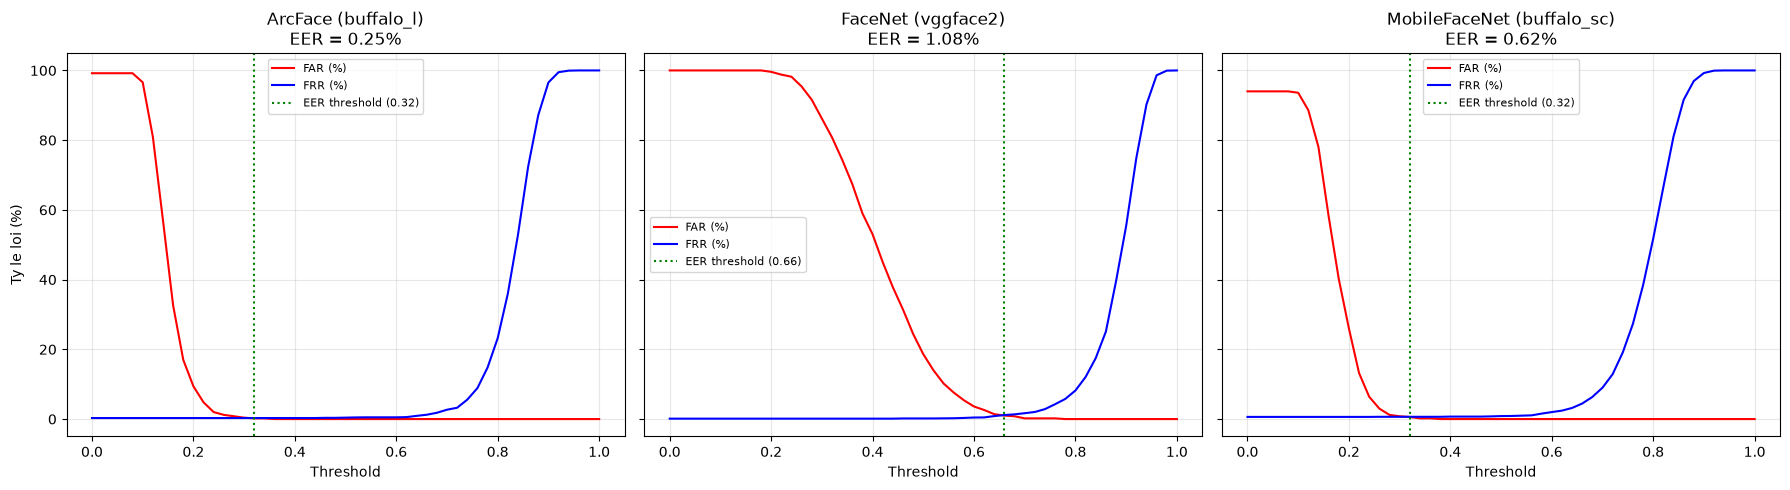

Da luu bieu do: D:\face-security-system\ai\dataset\evaluation_results\recognition_comparison_far_frr.png


In [16]:
# ===== CELL C6: Bieu do FAR/FRR theo threshold - 3 subplot canh nhau =====
import matplotlib.pyplot as plt

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, model_name in zip(axes, EMBEDDING_FUNCS.keys()):
        roc_df = roc_dfs[model_name]
        eer_row = eer_summary_df[eer_summary_df["model"] == model_name].iloc[0]

        ax.plot(roc_df["threshold"], roc_df["FAR"] * 100, label="FAR (%)", color="red")
        ax.plot(roc_df["threshold"], roc_df["FRR"] * 100, label="FRR (%)", color="blue")
        ax.axvline(eer_row["EER_threshold"], color="green", linestyle=":",
                    label=f"EER threshold ({eer_row['EER_threshold']:.2f})")
        ax.set_xlabel("Threshold")
        ax.set_title(f"{model_name}\nEER = {eer_row['EER (%)']:.2f}%")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Ty le loi (%)")
    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "recognition_comparison_far_frr.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu bieu do: {plot_path}")

## Phan D - Do toc do trich xuat embedding

Do thoi gian trich 1 embedding tren anh da crop san (khong tinh thoi gian detect nguoi/mat
tu frame goc - do rieng o Notebook 05). **Ca 3 model deu chay GPU trong notebook nay**
(khac ban dau du dinh dung Dlib CPU-only) - xem canh bao chi tiet o dau notebook - nen so
sanh FPS lan nay phan anh dung su khac biet ve KIEN TRUC (ResNet lon vs Inception vs
MobileNet nhe), khong bi nhieu boi viec 1 model bat buoc chay CPU.

In [17]:
# ===== CELL D1: Do thoi gian trich embedding tren N anh probe, cho ca 3 model =====
import time

N_WARMUP = 5
N_TIMED = 100

speed_rows = []

if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - gallery/probe chua san sang")
else:
    timing_images = []
    for person in sorted(os.listdir(SPLIT_PROBE)):
        for fname in os.listdir(os.path.join(SPLIT_PROBE, person)):
            img = cv2.imread(os.path.join(SPLIT_PROBE, person, fname))
            if img is not None:
                timing_images.append(img)
            if len(timing_images) >= N_WARMUP + N_TIMED:
                break
        if len(timing_images) >= N_WARMUP + N_TIMED:
            break

    for model_name, embed_fn in EMBEDDING_FUNCS.items():
        print(f"Dang do toc do {model_name}...")

        for img in timing_images[:N_WARMUP]:
            embed_fn(img)
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.time()
        for img in timing_images[N_WARMUP:N_WARMUP + N_TIMED]:
            embed_fn(img)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.time() - start

        n_processed = len(timing_images[N_WARMUP:N_WARMUP + N_TIMED])
        fps = n_processed / elapsed if elapsed > 0 else 0.0
        ms_per_image = (elapsed / n_processed) * 1000 if n_processed > 0 else 0.0

        speed_rows.append({
            "model": model_name, "fps": round(fps, 2), "ms_per_image": round(ms_per_image, 2),
        })

    speed_df = pd.DataFrame(speed_rows)
    print(f"\nToc do trich embedding (batch size = 1, tren anh da crop san, "
          f"{'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}):\n")
    print(speed_df.to_string(index=False))
    speed_df.to_csv(os.path.join(RESULTS_DIR, "recognition_comparison_speed.csv"), index=False)

Dang do toc do ArcFace (buffalo_l)...


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Dang do toc do FaceNet (vggface2)...
Dang do toc do MobileFaceNet (buffalo_sc)...

Toc do trich embedding (batch size = 1, tren anh da crop san, GPU: NVIDIA GeForce RTX 5070):

                     model   fps  ms_per_image
       ArcFace (buffalo_l) 20.95         47.73
        FaceNet (vggface2) 88.62         11.28
MobileFaceNet (buffalo_sc) 63.92         15.64


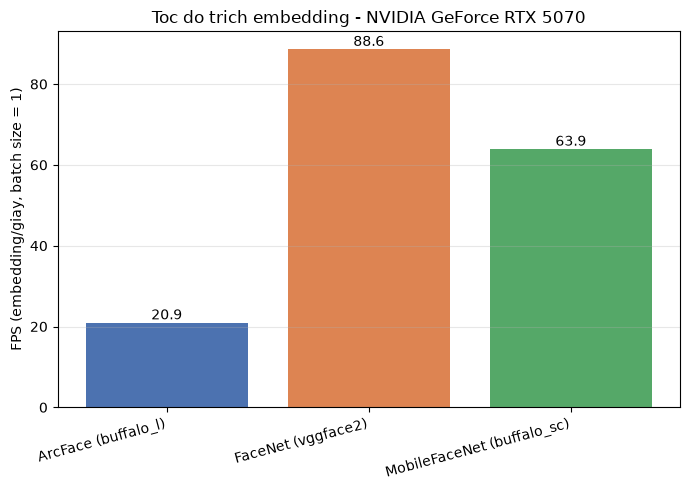

Da luu bieu do: D:\face-security-system\ai\dataset\evaluation_results\recognition_comparison_speed.png


In [18]:
# ===== CELL D2: Bieu do toc do =====
if not GALLERY_PROBE_AVAILABLE:
    print("Bo qua Cell nay - chua co ket qua toc do")
else:
    plt.figure(figsize=(7, 5))
    bars = plt.bar(speed_df["model"], speed_df["fps"], color=["#4C72B0", "#DD8452", "#55A868"])
    plt.ylabel("FPS (embedding/giay, batch size = 1)")
    plt.title("Toc do trich embedding - " + (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"))
    plt.xticks(rotation=15, ha="right")
    for bar, fps in zip(bars, speed_df["fps"]):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{fps:.1f}",
                  ha="center", va="bottom")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "recognition_comparison_speed.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu bieu do: {plot_path}")

## Phan E - Tong ket

**Ket qua luu trong `ai/dataset/evaluation_results/`:**
- `recognition_comparison_gallery_build_log.csv` - so anh/embedding thanh cong tung nguoi, tung model
- `recognition_comparison_eer_summary.csv` - EER, threshold toi uu, FAR/FRR tai EER cho ca 3 model
- `recognition_comparison_speed.csv` - FPS/ms-per-embedding
- `recognition_comparison_far_frr.png`, `recognition_comparison_speed.png` - bieu do

**Cach doc ket qua cho bao cao (Chuong 4):**
- So sanh chinh nen dua tren **EER** (Cell C4) - day la tieu chi cong bang vi moi model
  duoc xet tai threshold toi uu CUA RIENG NO, khac voi bang FAR/FRR tai threshold co dinh
  0.35 (Cell C5) chi mang tinh tham khao (0.35 duoc tune rieng cho ArcFace buffalo_l).
- Neu ArcFace (buffalo_l) co EER thap nhat - day la bang chung dinh luong cho quyet dinh
  kien truc da chot trong `ai/README.md`. Diem dang chu y: so sanh voi MobileFaceNet
  (buffalo_sc) cho thay CU THE cai gia phai tra khi chuyen sang model nhe hon (neu sau
  nay can toi uu cho thiet bi edge/mobile) - vi ca 2 deu dung insightface + ArcFace-style
  loss, chenh lech EER phan lon phan anh chenh lech kien truc backbone (ResNet50 vs
  MobileFaceNet nhe), khong bi nhieu boi khac biet ve loss function hay pipeline align
  nhu khi so voi FaceNet.
- Neu MobileFaceNet co EER cao hon ArcFace nhung FPS cao hon ro ret - day la minh chung
  cho danh doi kinh dien "do chinh xac doi lay toc do/kich thuoc model" trong thiet ke
  he thong nhan dien khuon mat, dang de cap trong bao cao khi giai thich tai sao du an
  chon buffalo_l (uu tien do chinh xac, camera an ninh co the chay server co GPU) thay vi
  buffalo_sc (uu tien toc do, phu hop edge device khong co GPU).
- Neu FaceNet dat EER khac biet ro so voi ca 2 model insightface - phu hop voi ly do ky
  thuat: Additive Angular Margin Loss (ArcFace/MobileFaceNet) duoc thiet ke chuyen biet
  de toi da hoa khoang cach lien-lop (inter-class) cho bai toan nhan dang, trong khi
  Triplet Loss (FaceNet) can chien luoc chon triplet (mining) phu hop moi dat hieu qua
  tot nhat - vgg2-pretrained co san co the chua toi uu tuyet doi cho phan bo du lieu cu
  the cua do an nay.

**Luu y quan trong khi doc bang so lieu:**
- `MAX_STRANGER_IMAGES=500` (Cell C3, giong Notebook 04) chi la mot phan cua LFW - tang len
  neu muon EER on dinh hon cho bao cao chinh thuc, chap nhan doi lau hon.
- Gallery/probe dang dung la **LFW qua Notebook 01** (du lieu demo, xem ghi chu trong chinh
  Notebook 01) - khi co du lieu enrollment that cua do an (anh nguoi dung/nhan vien that), nen
  chay lai notebook nay tren du lieu that truoc khi ket luan cuoi cung, vi phan bo anh LFW
  (chup studio, anh sang tot) khac han dieu kien camera an ninh thuc te.
- Ca 3 model deu dang do tren **anh da crop/align san 112x112** (dau ra cua Notebook 01),
  KHONG qua buoc YOLOv8 person-detection + crop truoc nhu pipeline that trong
  `pipeline_runner.py` - day la so sanh cong bang cho rieng ban than encoder, khac voi
  hieu nang end-to-end cua toan cascade (detection + recognition + tracking).